## 6. This model transforms political news into a causally linked narrative graph, enabling strategic interpretation

Nodes: 36, Edges: 46


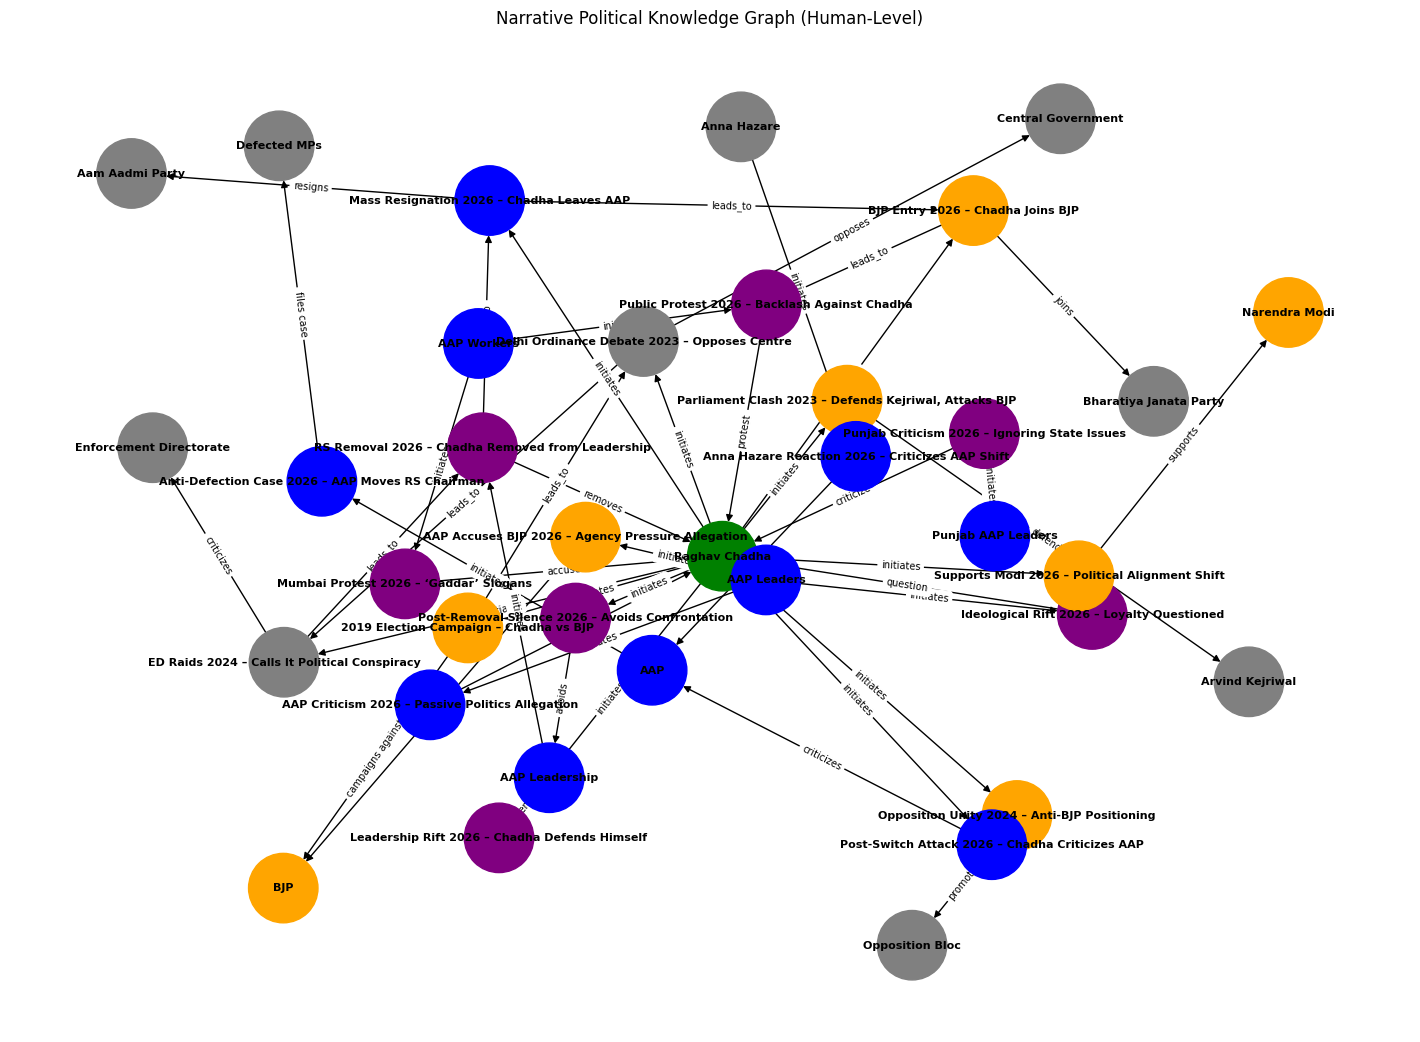

In [44]:
# ==============================
# 1. INSTALL & IMPORT LIBRARIES
# ==============================


import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATA
# ==============================
def load_data():
    df = pd.read_csv("raghav_chadha_corpus.csv")
    df["Cleaned_Text"] = df["Text"].str.lower()
    return df

# ==============================
# 3. MANUAL EVENT DEFINITIONS
# ==============================

EVENTS = {
    "E1": {"title": "2019 Election Campaign – Chadha vs BJP", "actor": "Raghav Chadha", "action": "campaigns against", "target": "BJP", "year": 2019},
    "E2": {"title": "Delhi Ordinance Debate 2023 – Opposes Centre", "actor": "Raghav Chadha", "action": "opposes", "target": "Central Government", "year": 2023},
    "E3": {"title": "Parliament Clash 2023 – Defends Kejriwal, Attacks BJP", "actor": "Raghav Chadha", "action": "defends", "target": "Arvind Kejriwal", "year": 2023},
    "E4": {"title": "ED Raids 2024 – Calls It Political Conspiracy", "actor": "Raghav Chadha", "action": "criticizes", "target": "Enforcement Directorate", "year": 2024},
    "E5": {"title": "Opposition Unity 2024 – Anti-BJP Positioning", "actor": "Raghav Chadha", "action": "promotes", "target": "Opposition Bloc", "year": 2024},

    "E6": {"title": "AAP Criticism 2026 – Passive Politics Allegation", "actor": "AAP Leaders", "action": "accuse", "target": "Raghav Chadha", "year": 2026},
    "E7": {"title": "Leadership Rift 2026 – Chadha Defends Himself", "actor": "Raghav Chadha", "action": "defends", "target": "AAP Leadership", "year": 2026},
    "E8": {"title": "RS Removal 2026 – Chadha Removed from Leadership", "actor": "AAP Leadership", "action": "removes", "target": "Raghav Chadha", "year": 2026},
    "E9": {"title": "Post-Removal Silence 2026 – Avoids Confrontation", "actor": "Raghav Chadha", "action": "avoids", "target": "AAP Leadership", "year": 2026},
    "E10": {"title": "Punjab Criticism 2026 – Ignoring State Issues", "actor": "Punjab AAP Leaders", "action": "criticize", "target": "Raghav Chadha", "year": 2026},
    "E11": {"title": "Ideological Rift 2026 – Loyalty Questioned", "actor": "AAP Leaders", "action": "question", "target": "Raghav Chadha", "year": 2026},

    "E12": {"title": "Mass Resignation 2026 – Chadha Leaves AAP", "actor": "Raghav Chadha", "action": "resigns", "target": "Aam Aadmi Party", "year": 2026},
    "E13": {"title": "BJP Entry 2026 – Chadha Joins BJP", "actor": "Raghav Chadha", "action": "joins", "target": "Bharatiya Janata Party", "year": 2026},
    "E14": {"title": "Supports Modi 2026 – Political Alignment Shift", "actor": "Raghav Chadha", "action": "supports", "target": "Narendra Modi", "year": 2026},

    "E15": {"title": "AAP Accuses BJP 2026 – Agency Pressure Allegation", "actor": "AAP Leaders", "action": "accuse", "target": "BJP", "year": 2026},
    "E16": {"title": "Public Protest 2026 – Backlash Against Chadha", "actor": "AAP Workers", "action": "protest", "target": "Raghav Chadha", "year": 2026},
    "E17": {"title": "Mumbai Protest 2026 – ‘Gaddar’ Slogans", "actor": "AAP Workers", "action": "accuse", "target": "Raghav Chadha", "year": 2026},
    "E18": {"title": "Anti-Defection Case 2026 – AAP Moves RS Chairman", "actor": "AAP", "action": "files case", "target": "Defected MPs", "year": 2026},
    "E19": {"title": "Anna Hazare Reaction 2026 – Criticizes AAP Shift", "actor": "Anna Hazare", "action": "criticizes", "target": "AAP", "year": 2026},
    "E20": {"title": "Post-Switch Attack 2026 – Chadha Criticizes AAP", "actor": "Raghav Chadha", "action": "criticizes", "target": "AAP", "year": 2026},
}

# ==============================
# 4. BUILD STORY GRAPH
# ==============================

def build_story_graph():
    G = nx.DiGraph()

    # Add central node
    G.add_node("Raghav Chadha", type="central")

    for eid, e in EVENTS.items():
        event_node = e["title"]

        # Add event node
        G.add_node(event_node, type="event", year=e["year"])

        # Add entities
        G.add_node(e["actor"], type="actor")
        G.add_node(e["target"], type="target")

        # Connect graph
        G.add_edge(e["actor"], event_node, relation="initiates")
        G.add_edge(event_node, e["target"], relation=e["action"])

    return G

# ==============================
# 5. ADD CAUSAL FLOW (STORYLINE)
# ==============================

def add_causal_edges(G):
    flow = [
        "2019 Election Campaign – Chadha vs BJP",
        "Delhi Ordinance Debate 2023 – Opposes Centre",
        "ED Raids 2024 – Calls It Political Conspiracy",
        "RS Removal 2026 – Chadha Removed from Leadership",
        "Mass Resignation 2026 – Chadha Leaves AAP",
        "BJP Entry 2026 – Chadha Joins BJP",
        "Public Protest 2026 – Backlash Against Chadha"
    ]

    for i in range(len(flow)-1):
        G.add_edge(flow[i], flow[i+1], relation="leads_to")

    return G

# ==============================
# 6. VISUALIZATION
# ==============================

def get_color(node):
    if "Raghav Chadha" in node:
        return "green"
    elif "BJP" in node or "Modi" in node:
        return "orange"
    elif "AAP" in node:
        return "blue"
    elif "2026" in node or "Election" in node:
        return "purple"
    else:
        return "gray"

def visualize(G, title):
    plt.figure(figsize=(14,10))
    pos = nx.spring_layout(G, k=0.6, seed=42)

    node_colors = [get_color(n) for n in G.nodes()]
    edge_labels = {(u,v): G[u][v]['relation'] for u,v in G.edges()}

    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=2500, font_size=8, font_weight='bold')

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    plt.title(title)
    plt.show()

# ==============================
# 7. MAIN EXECUTION
# ==============================

def main():
    G = build_story_graph()
    G = add_causal_edges(G)

    print(f"Nodes: {len(G.nodes())}, Edges: {len(G.edges())}")
    visualize(G, "Narrative Political Knowledge Graph (Human-Level)")

if __name__ == "__main__":
    main()